# Face Detection with Haar Cascades

**Note: This is face *detection* NOT face *recognition*. We are only detecting if a face is in an image, not who the face actually is. That requires deep learning.**

## 1) Load and Display Images

- Step 1: Import necessary packages: numpy, cv2, matplotlib.pyplot
- Step 2: Load grayscale images using cv2.imread() with flag 0
- Step 3: Display images using plt.imshow() with cmap='gray'

In [1]:
import numpy as np
import cv2 
import matplotlib.pyplot as plt
%matplotlib inline

## Images

In [2]:
with_glass = cv2.imread('image_01.png')
with_out_glass = cv2.imread('image_02.png')
group_photo = cv2.imread('image_03.png')

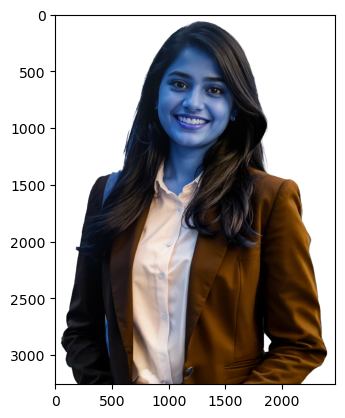

In [3]:
plt.imshow(with_glass,cmap='gray')

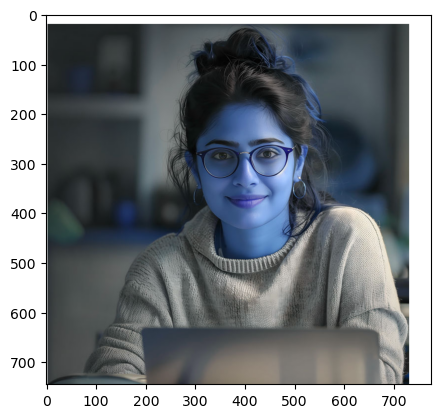

In [4]:
plt.imshow(with_out_glass,cmap='gray')

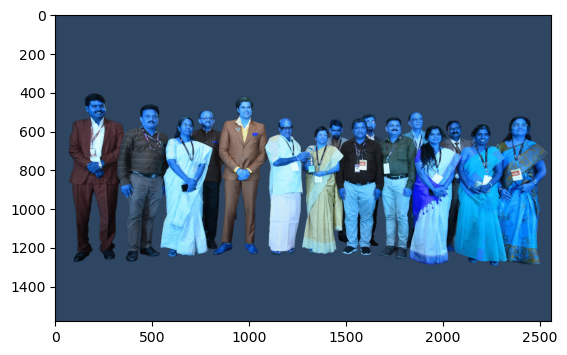

In [5]:
plt.imshow(group_photo,cmap='gray')

## II) Load Haar Cascade Classifiers

- Step 1: Load face and eye cascade XML files

## Face Detection

In [6]:
face_cascade = cv2.CascadeClassifier('haarcascade_frontalface_default.xml')

## III) Perform Face Detection in Images

- Step 1: Define a function detect_face() that copies the input image
- Step 2: Use face_cascade.detectMultiScale() to detect faces
- Step 3: Draw white rectangles around detected faces with thickness 10
- Step 4: Return the processed image with rectangles

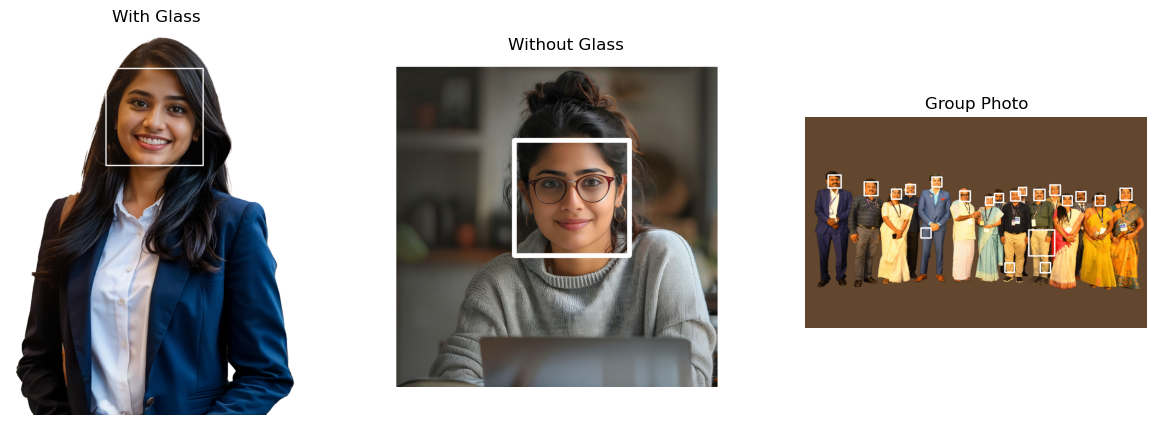

In [7]:

# Step 1: Define function
def detect_face(image):

    # Copy the input image
    img_copy = image.copy()

    # Convert to grayscale
    gray = cv2.cvtColor(img_copy, cv2.COLOR_BGR2GRAY)

    # Step 2: Detect faces
    faces = face_cascade.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=5
    )

    # Step 3: Draw white rectangles
    for (x, y, w, h) in faces:
        cv2.rectangle(
            img_copy,
            (x, y),
            (x+w, y+h),
            (255,255,255),   # White color
            10               # Thickness
        )

    # Step 4: Return processed image
    return img_copy


# Apply face detection on 3 images
result1 = detect_face(with_glass)
result2 = detect_face(with_out_glass)
result3 = detect_face(group_photo)

# Display results
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(cv2.cvtColor(result1, cv2.COLOR_BGR2RGB))
plt.title("With Glass")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(cv2.cvtColor(result2, cv2.COLOR_BGR2RGB))
plt.title("Without Glass")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(cv2.cvtColor(result3, cv2.COLOR_BGR2RGB))
plt.title("Group Photo")
plt.axis('off')

plt.show()

## IV) Perform Eye Detection in Images & Display Detection Results on Images

- Step 1: Define a function detect_eyes() that copies the input image
- Step 2: Use eye_cascade.detectMultiScale() to detect eyes
- Step 3: Draw white rectangles around detected eyes with thickness 10
- Step 4: Return the processed image with rectangles
- Step 5: Call detect_face() or detect_eyes() on loaded images
- Step 6: Use plt.imshow() with cmap='gray' to display images with detected regions highlighted

In [8]:
eye_cascade = cv2.CascadeClassifier('haarcascade_eye.xml')

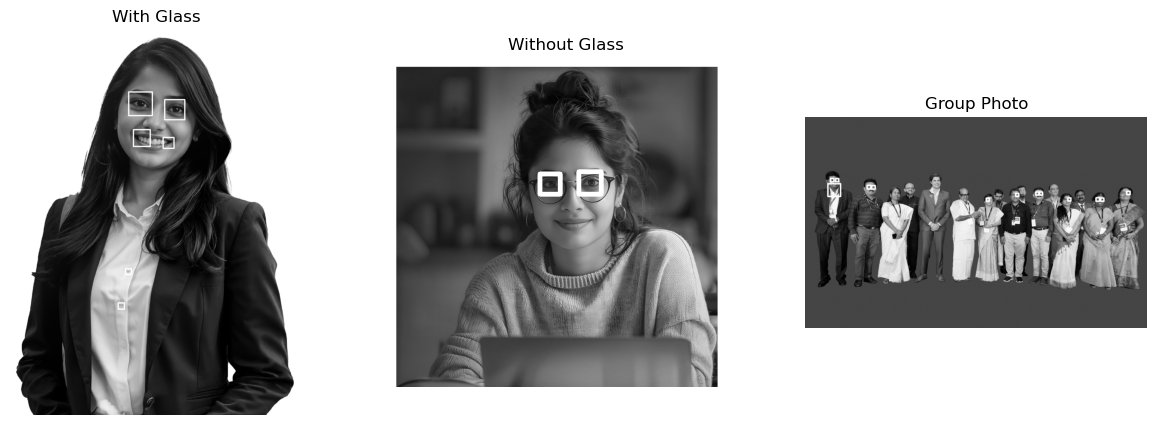

In [9]:

# Step 1: Define detect_eyes() function
def detect_eyes(image):

    # Copy input image
    img_copy = image.copy()

    # Convert image to grayscale
    gray = cv2.cvtColor(img_copy, cv2.COLOR_BGR2GRAY)

    # Step 2: Detect eyes
    eyes = eye_cascade.detectMultiScale(gray, 1.1, 5)

    # Step 3: Draw white rectangles around eyes
    for (x, y, w, h) in eyes:
        cv2.rectangle(img_copy,
                      (x, y),
                      (x+w, y+h),
                      (255,255,255),  # White color
                      10)             # Thickness

    # Step 4: Return processed image
    return img_copy


# Step 5: Call detect_eyes() on loaded images
eye_img1 = detect_eyes(with_glass)
eye_img2 = detect_eyes(with_out_glass)
eye_img3 = detect_eyes(group_photo)

# Step 6: Display images using cmap='gray'
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(cv2.cvtColor(eye_img1, cv2.COLOR_BGR2GRAY), cmap='gray')
plt.title("With Glass")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(cv2.cvtColor(eye_img2, cv2.COLOR_BGR2GRAY), cmap='gray')
plt.title("Without Glass")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(cv2.cvtColor(eye_img3, cv2.COLOR_BGR2GRAY), cmap='gray')
plt.title("Group Photo")
plt.axis('off')

plt.show()

## VI) Perform Face Detection on Real-Time Webcam Video

- Step 1: Capture video from webcam using cv2.VideoCapture(0)
- Step 2: Loop to continuously read frames from webcam
- Step 3: Apply detect_face() function on each frame
- Step 4: Display the video frame with rectangles around detected faces
- Step 5: Exit loop and close windows when ESC key (key code 27) is pressed
- Step 6: Release video capture and destroy all OpenCV windows

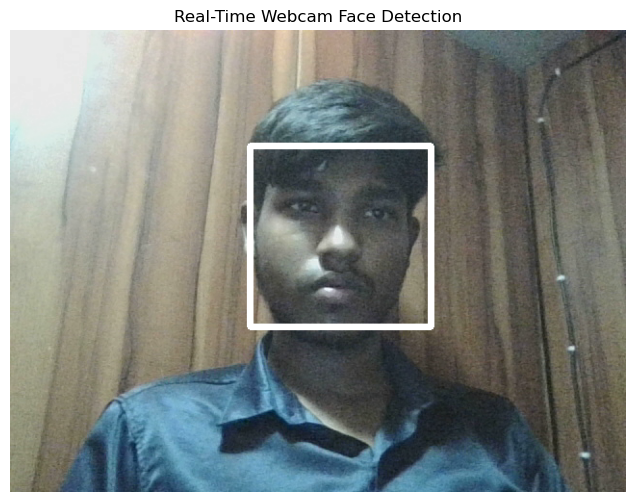

KeyboardInterrupt: 

In [12]:
import cv2
import matplotlib.pyplot as plt
from IPython.display import clear_output

# Load Haar Cascade
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades +
    'haarcascade_frontalface_default.xml'
)

# Face Detection Function
def detect_face(frame):

    img = frame.copy()

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    faces = face_cascade.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=5
    )

    # Draw rectangles around faces
    for (x,y,w,h) in faces:
        cv2.rectangle(
            img,
            (x,y),
            (x+w,y+h),
            (255,255,255),
            5
        )

    return img


# Step 1: Capture webcam video
cap = cv2.VideoCapture(0)

# Step 2: Real-time loop
while True:

    ret, frame = cap.read()

    if not ret:
        break

    # Step 3: Detect faces
    detected = detect_face(frame)

    # Convert BGR → RGB
    detected = cv2.cvtColor(
        detected,
        cv2.COLOR_BGR2RGB
    )

    # Step 4: Display real-time frame
    clear_output(wait=True)

    plt.figure(figsize=(8,6))
    plt.imshow(detected)
    plt.title("Real-Time Webcam Face Detection")
    plt.axis('off')
    plt.show()

    # Step 5: Press Stop button in notebook to exit

# Step 6: Release webcam
cap.release()